In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import optim

# For reproducability
torch.manual_seed(0)

In [2]:
class MNISTConvNet(nn.Module):
  def __init__(self):
    super(MNISTConvNet, self).__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(1, 32, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(32, 64, 5, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64, 1024),
        nn.Dropout(0.5),
        nn.Linear(1024, 10)
    )

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    return self.fc1(x)

In [3]:
trainset = MNIST('.', train=True, download=True, 
                      transform=ToTensor())
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

In [4]:
# # Testing cpu training time
# lr = 1e-4
# num_epochs = 5

# device = 'cpu'
# model_nocuda = MNISTConvNet().to(device)
# loss_fn = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model_nocuda.parameters(), lr=lr)

# for epochs in range(num_epochs):
#   running_loss = 0.0
#   num_correct = 0
#   for inputs, labels in trainloader:
#     optimizer.zero_grad()
#     outputs = model_nocuda(inputs.to(device))
#     loss = loss_fn(outputs, labels.to(device))
#     loss.backward()
#     running_loss += loss.item()
#     optimizer.step()
#     _, idx = outputs.max(dim=1)
#     num_correct += (idx == labels.to(device)).sum().item()
#   print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
#         num_correct/len(trainloader)))
  
#   # ~60s per epoch on CPU

In [ ]:
# Define model as class with "forward" method
# Define loss function
# Define optimization algorithm (input model parameters, learning rate)
# For each epoch:
#   For each batch:
#     Set gradients to zero - optimizer.zero_grad()
#     Calculate outputs - model(inputs)
#     Calculate loss - loss_fn(outputs, labels)
#     Update gradients - loss.backward()
#     Update parameters - optimizer.step()

In [5]:
lr = 1e-4
num_epochs = 40

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MNISTConvNet().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

for epochs in range(num_epochs):
  running_loss = 0.0
  num_correct = 0
  for inputs, labels in trainloader:
    optimizer.zero_grad()
    outputs = model(inputs.to(device))
    loss = loss_fn(outputs, labels.to(device))
    loss.backward()
    running_loss += loss.item()
    optimizer.step()
    _, idx = outputs.max(dim=1)
    num_correct += (idx == labels.to(device)).sum().item()
  print('Loss: {} Accuracy: {}'.format(running_loss/len(trainloader),
        num_correct/len(trainloader)))
  
  # ~13s per epoch w/ CUDA

Loss: 2.2975001993464 Accuracy: 7.398720682302772
Loss: 2.2879916038086163 Accuracy: 9.405117270788912
Loss: 2.2775835945153795 Accuracy: 12.028784648187633
Loss: 2.2672094157509712 Accuracy: 15.142857142857142
Loss: 2.2553249897478995 Accuracy: 18.791044776119403
Loss: 2.2419688953265453 Accuracy: 21.80277185501066
Loss: 2.22714637972907 Accuracy: 24.73454157782516
Loss: 2.2100306134234105 Accuracy: 27.14179104477612
Loss: 2.189796628219995 Accuracy: 30.05223880597015
Loss: 2.165863134459392 Accuracy: 32.31236673773987
Loss: 2.1370776647697887 Accuracy: 34.32089552238806
Loss: 2.1022682073019716 Accuracy: 36.25159914712154
Loss: 2.0606027081577 Accuracy: 37.74307036247335
Loss: 2.0088615524235056 Accuracy: 39.10554371002132
Loss: 1.945731953644295 Accuracy: 40.18976545842217
Loss: 1.8684628638885676 Accuracy: 41.13859275053305
Loss: 1.7762968394039536 Accuracy: 42.10554371002132
Loss: 1.6689963957139933 Accuracy: 42.946695095948826
Loss: 1.5489568612468776 Accuracy: 43.93816631130064


ACTUAL: 8
MODEL OUTPUT: 8


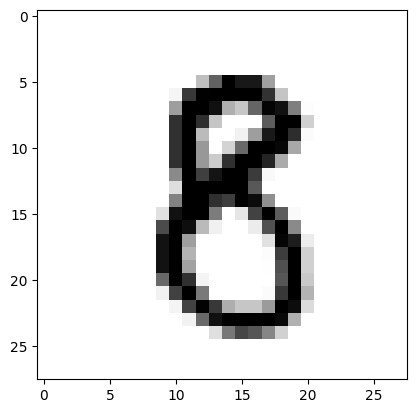

ACTUAL: 9
MODEL OUTPUT: 4


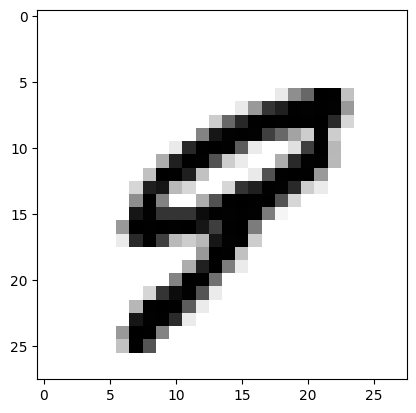

ACTUAL: 1
MODEL OUTPUT: 1


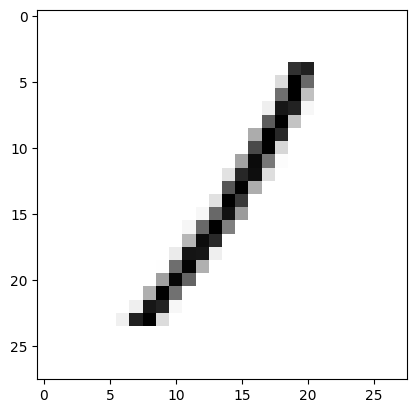

ACTUAL: 9
MODEL OUTPUT: 9


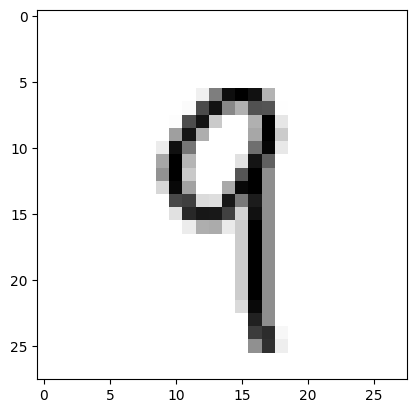

ACTUAL: 2
MODEL OUTPUT: 2


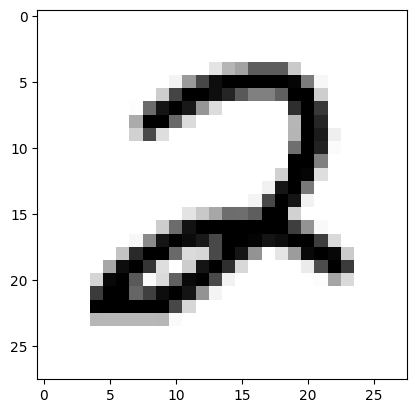

ACTUAL: 3
MODEL OUTPUT: 2


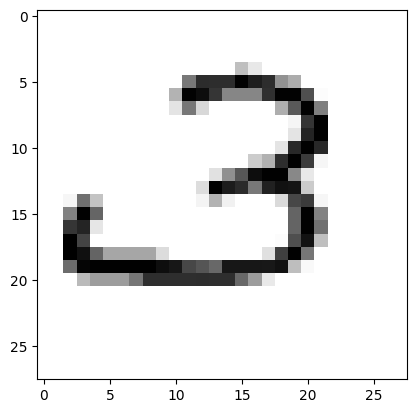

ACTUAL: 5
MODEL OUTPUT: 5


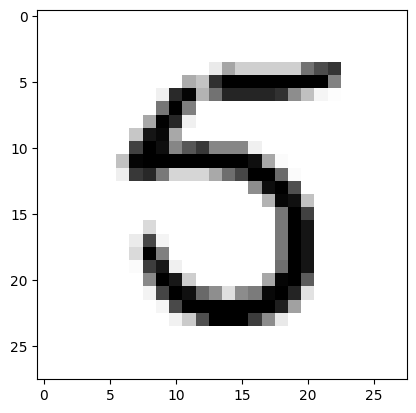

ACTUAL: 4
MODEL OUTPUT: 4


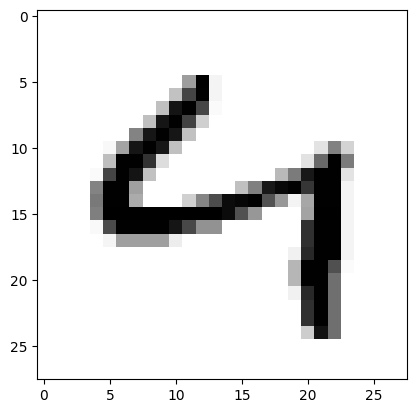

ACTUAL: 9
MODEL OUTPUT: 7


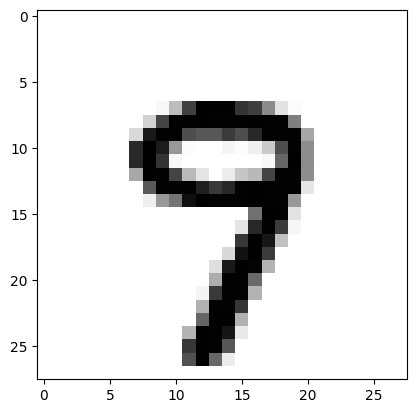

ACTUAL: 6
MODEL OUTPUT: 6


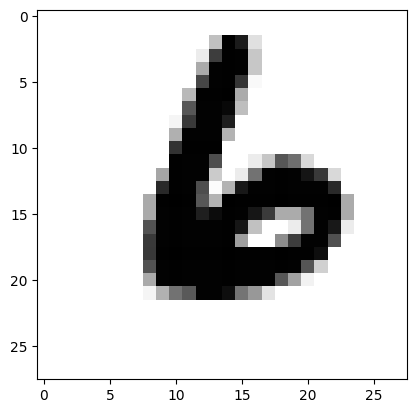

ACTUAL: 1
MODEL OUTPUT: 1


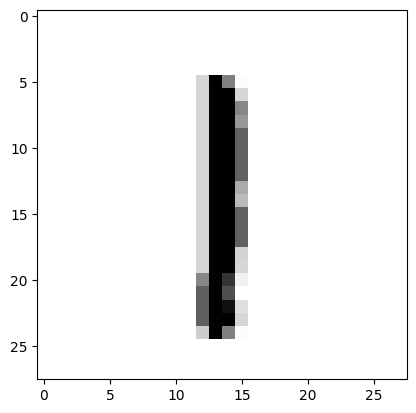

ACTUAL: 2
MODEL OUTPUT: 2


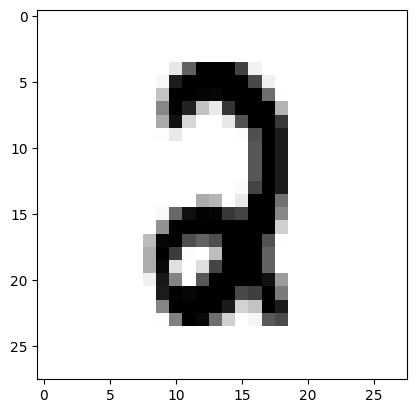

ACTUAL: 2
MODEL OUTPUT: 2


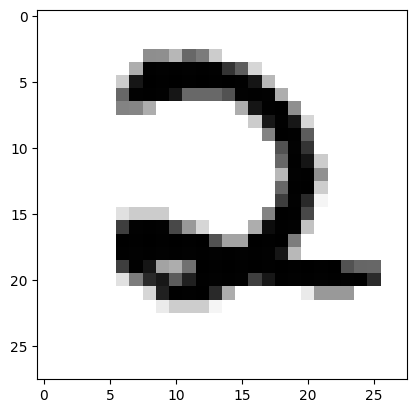

ACTUAL: 4
MODEL OUTPUT: 4


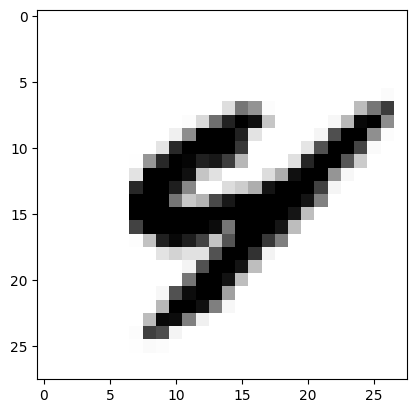

ACTUAL: 8
MODEL OUTPUT: 5


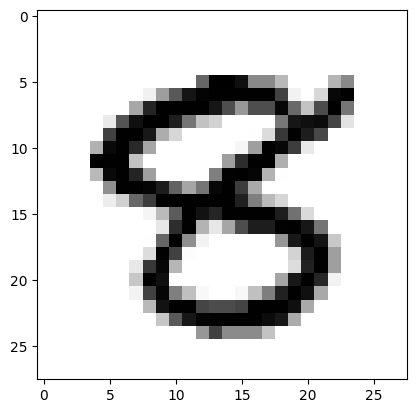

ACTUAL: 8
MODEL OUTPUT: 4


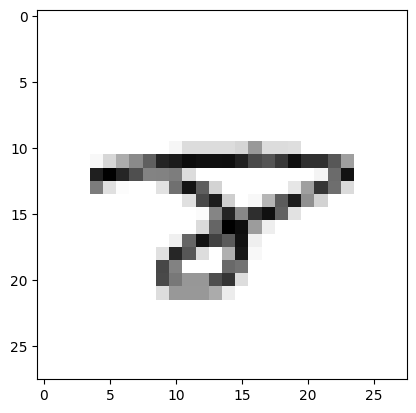

ACTUAL: 8
MODEL OUTPUT: 8


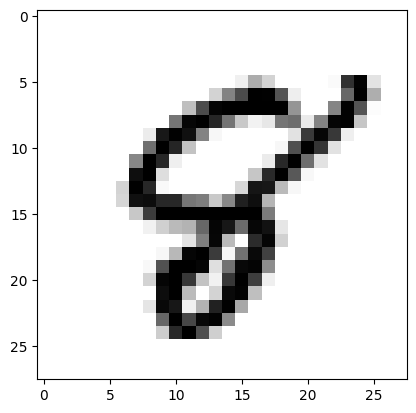

ACTUAL: 7
MODEL OUTPUT: 7


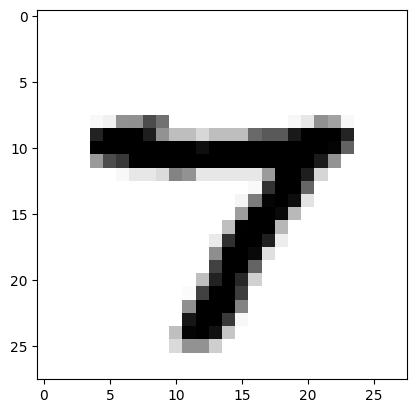

ACTUAL: 3
MODEL OUTPUT: 9


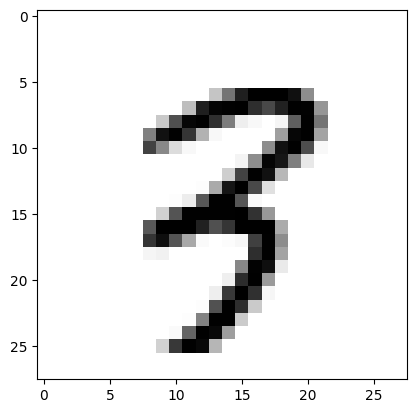

ACTUAL: 4
MODEL OUTPUT: 4


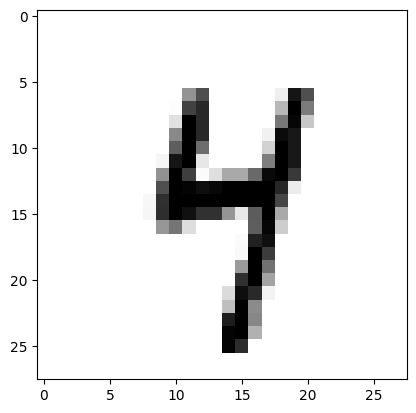

ACTUAL: 3
MODEL OUTPUT: 2


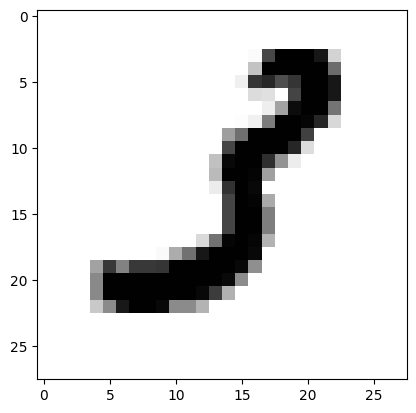

ACTUAL: 8
MODEL OUTPUT: 8


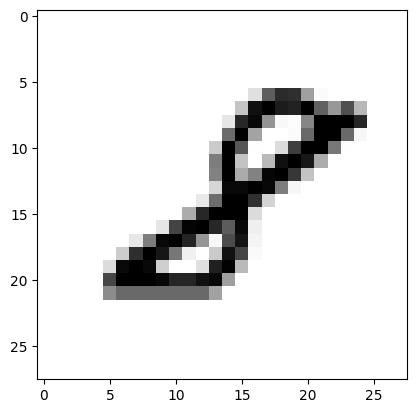

ACTUAL: 0
MODEL OUTPUT: 0


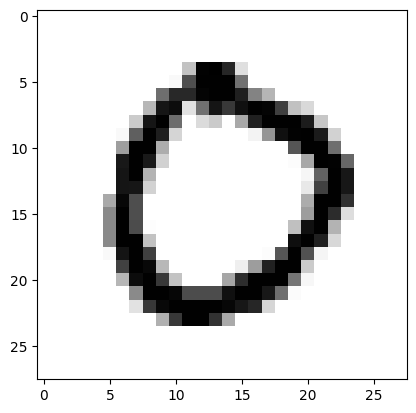

ACTUAL: 1
MODEL OUTPUT: 1


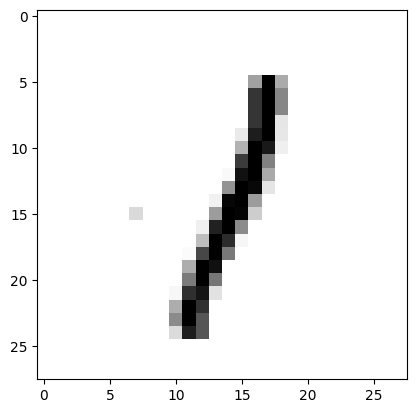

ACTUAL: 8
MODEL OUTPUT: 3


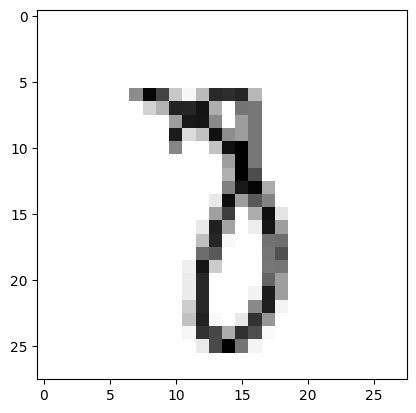

ACTUAL: 7
MODEL OUTPUT: 7


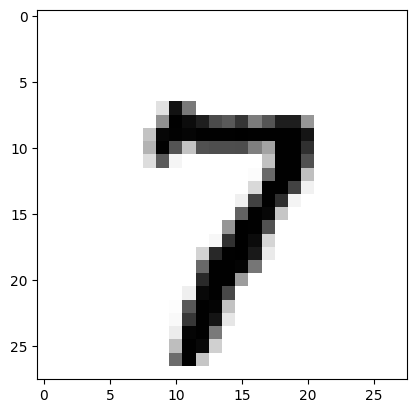

ACTUAL: 6
MODEL OUTPUT: 6


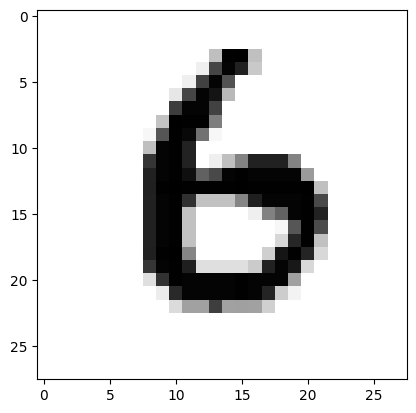

ACTUAL: 0
MODEL OUTPUT: 0


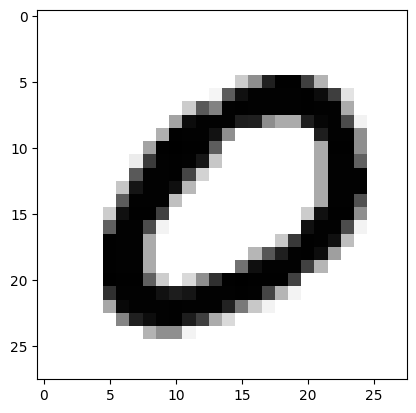

ACTUAL: 1
MODEL OUTPUT: 1


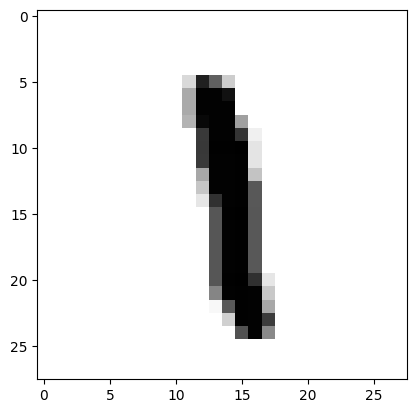

ACTUAL: 9
MODEL OUTPUT: 7


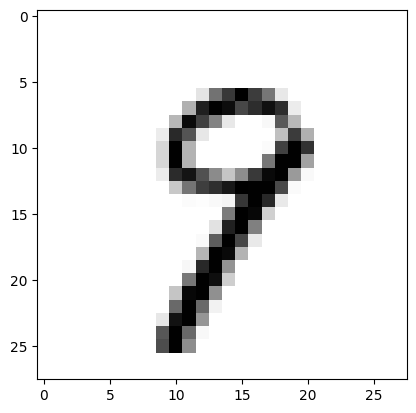

ACTUAL: 4
MODEL OUTPUT: 4


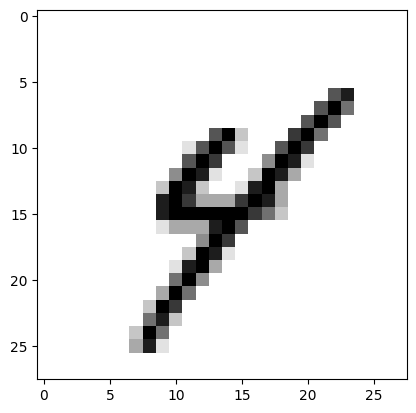

ACTUAL: 8
MODEL OUTPUT: 8


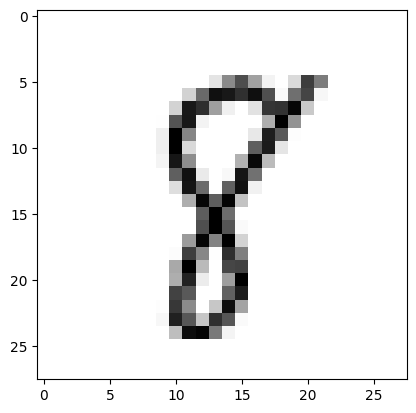

In [7]:
import matplotlib.pyplot as plt
for i in range(32):
    print("ACTUAL:", labels.numpy()[i])
    print("MODEL OUTPUT:", idx.cpu().numpy()[i])
    plt.imshow(inputs.numpy()[i, 0], cmap='gray_r')
    plt.show()